# YouTube Oracle — v0 Model

Training a virality classifier on the Kaggle trending dataset.

**Goal:** Predict whether a video will become "viral" (1M+ views) based on features we can compute early — title, channel, category, publish timing, tags.

**Data:** 40K US trending videos from Kaggle (2017–2018). Each row = one video on one day it was trending. We'll deduplicate to one row per video (first time it appeared in trending).

**Why this threshold?** The Kaggle dataset only contains videos that made it to trending in the first place, so they're all already somewhat popular. Within that pool, 1M views is a meaningful "viral" line. When we retrain on our own data in Week 3, we'll use a different threshold since we'll have a wider view distribution.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')

DATA_PATH = Path('../data/kaggle/USvideos.csv')
print('File exists:', DATA_PATH.exists())
print('Size:', DATA_PATH.stat().st_size / 1e6, 'MB')

File exists: True
Size: 62.756152 MB


## 1. Load and peek

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (40949, 16)


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...


In [4]:
# What columns do we have?
df.dtypes

video_id                    str
trending_date               str
title                       str
channel_title               str
category_id               int64
publish_time                str
tags                        str
views                     int64
likes                     int64
dislikes                  int64
comment_count             int64
thumbnail_link              str
comments_disabled          bool
ratings_disabled           bool
video_error_or_removed     bool
description                 str
dtype: object

## 2. Deduplicate — one row per video

Each video appears multiple times (once per day it was trending). We want one row per video, using its first trending appearance — that's the earliest snapshot we have and best mimics what our production model will see.

In [5]:
# Convert trending_date and publish_time to datetime
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Sort by trending_date and keep first appearance per video
df_first = df.sort_values('trending_date').drop_duplicates('video_id', keep='first').copy()
print(f'Unique videos: {len(df_first):,}')

# Also get the MAX views per video — this becomes our label
max_views = df.groupby('video_id')['views'].max().rename('max_views')
df_first = df_first.merge(max_views, on='video_id')
df_first['max_views'].describe()

Unique videos: 6,351


count    6.351000e+03
mean     1.963852e+06
std      7.061186e+06
min      5.590000e+02
25%      1.591565e+05
50%      5.181070e+05
75%      1.474750e+06
max      2.252119e+08
Name: max_views, dtype: float64

## 3. Create the target label

`went_viral = 1` if max_views >= 1M, else 0.

In [7]:
VIRAL_THRESHOLD = 1_000_000
df_first['went_viral'] = (df_first['max_views'] >= VIRAL_THRESHOLD).astype(int)

viral_rate = df_first['went_viral'].mean()
print(f'Viral rate: {viral_rate:.1%} ({df_first["went_viral"].sum():,} of {len(df_first):,})')

# Quick sanity check — viral distribution by category
import json
with open('../data/kaggle/US_category_id.json') as f:
    cat_data = json.load(f)
cat_map = {int(item['id']): item['snippet']['title'] for item in cat_data['items']}
df_first['category_name'] = df_first['category_id'].map(cat_map)

df_first.groupby('category_name')['went_viral'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)

Viral rate: 34.3% (2,176 of 6,351)


,mean,count
category_name,,
Entertainment,0.365658,1619
Music,0.518148,799
Howto & Style,0.247059,595
Comedy,0.451554,547
News & Politics,0.130693,505
People & Blogs,0.321285,498
Sports,0.274945,451
Science & Technology,0.284211,380
Film & Animation,0.490566,318


## 4. Feature engineering

Build features that mirror what we'll have in production (catching videos at ~6 hours old):
- Title features: length, word count, has question mark, has exclamation, all caps count
- Publish timing: hour of day, day of week
- Content features: category, tag count, description length
- Early signal: likes/views ratio, comments/views ratio at first trending snapshot

In [9]:
def engineer_features(df):
    out = df.copy()
    
    # Title features
    out['title_length'] = out['title'].str.len()
    out['title_word_count'] = out['title'].str.split().str.len()
    out['title_has_question'] = out['title'].str.contains(r'\?', regex=True).astype(int)
    out['title_has_exclaim'] = out['title'].str.contains(r'!', regex=True).astype(int)
    out['title_caps_ratio'] = out['title'].apply(
        lambda s: sum(1 for c in str(s) if c.isupper()) / max(len(str(s)), 1)
    )
    out['title_has_number'] = out['title'].str.contains(r'\d', regex=True).astype(int)
    
    # Publish timing
    out['publish_hour'] = out['publish_time'].dt.hour
    out['publish_dayofweek'] = out['publish_time'].dt.dayofweek
    out['publish_is_weekend'] = (out['publish_dayofweek'] >= 5).astype(int)
    
    # Content features
    out['tag_count'] = out['tags'].fillna('').str.count(r'\|') + 1
    out['tag_count'] = out['tag_count'].where(out['tags'].notna() & (out['tags'] != '[none]'), 0)
    out['description_length'] = out['description'].fillna('').str.len()
    out['description_has_link'] = out['description'].fillna('').str.contains(r'http', regex=True).astype(int)
    
    # Early engagement ratios (at first trending snapshot)
    out['like_rate'] = out['likes'] / (out['views'] + 1)
    out['comment_rate'] = out['comment_count'] / (out['views'] + 1)
    out['dislike_rate'] = out['dislikes'] / (out['views'] + 1)
    
    # Time-to-trending (how many hours between publish and first trending)
    # Normalize both to tz-naive to avoid mismatch
    pub = pd.to_datetime(out['publish_time'], utc=True).dt.tz_localize(None)
    trend = pd.to_datetime(out['trending_date'])
    if trend.dt.tz is not None:
        trend = trend.dt.tz_localize(None)
    hours_to_trending = (trend - pub).dt.total_seconds() / 3600
    out['hours_to_trending'] = hours_to_trending.clip(lower=0)
    
    return out

df_feat = engineer_features(df_first)
print(f'Engineered features. Shape: {df_feat.shape}')

feature_cols = [
    'title_length', 'title_word_count', 'title_has_question', 'title_has_exclaim',
    'title_caps_ratio', 'title_has_number',
    'publish_hour', 'publish_dayofweek', 'publish_is_weekend',
    'category_id', 'tag_count',
    'description_length', 'description_has_link',
    'views', 'likes', 'dislikes', 'comment_count',
    'like_rate', 'comment_rate', 'dislike_rate',
    'hours_to_trending',
]
print(f'Using {len(feature_cols)} features')
df_feat[feature_cols].head(3)

Engineered features. Shape: (6351, 35)
Using 21 features


,title_length,title_word_count,title_has_question,title_has_exclaim,title_caps_ratio,title_has_number,publish_hour,publish_dayofweek,publish_is_weekend,category_id,tag_count,description_length,description_has_link,views,likes,dislikes,comment_count,like_rate,comment_rate,dislike_rate,hours_to_trending
0,34,7,0,0,0.823529,0,17,0,0,22,1,1410,1,748374,57527,2966,15954,0.076869,0.021318,0.003963,6.783056
1,45,10,0,0,0.377778,0,21,4,0,10,31,813,1,98422,2926,106,798,0.029729,0.008108,0.001077,74.350833
2,34,7,0,0,0.294118,0,13,3,0,15,44,1489,1,426078,19323,245,945,0.045351,0.002218,0.000575,106.417222


## 5. Quick EDA — which features actually correlate with going viral?

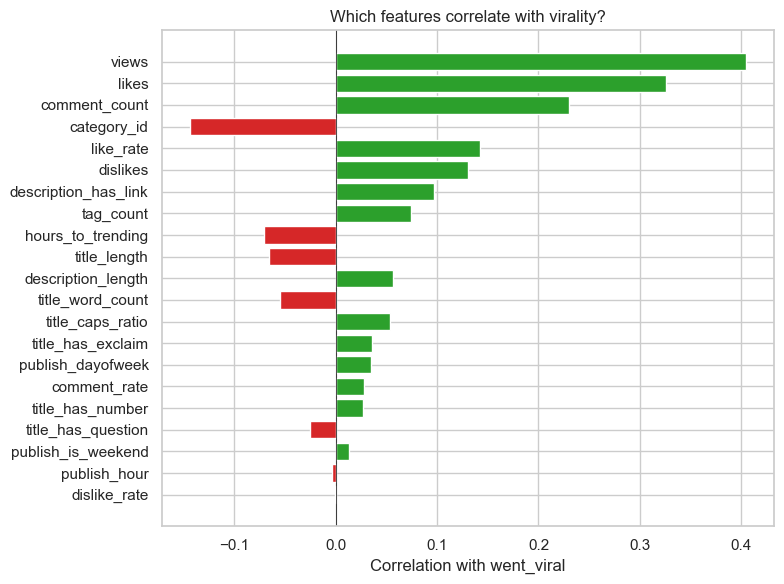

Top 5 correlates:
views            0.404892
likes            0.326107
comment_count    0.230384
category_id     -0.144097
like_rate        0.142696
Name: went_viral, dtype: float64


In [10]:
# Correlation with the target
corr = df_feat[feature_cols + ['went_viral']].corr()['went_viral'].drop('went_viral').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tab:green' if v > 0 else 'tab:red' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Correlation with went_viral')
ax.set_title('Which features correlate with virality?')
plt.tight_layout()
plt.show()

print('Top 5 correlates:')
print(corr.head())

## 6. Train XGBoost

Time-based split — train on older data, test on newer. This prevents leakage and mimics real production conditions.

In [11]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, precision_recall_curve
)

# Time-based split: earliest 80% train, latest 20% test
df_sorted = df_feat.sort_values('trending_date').reset_index(drop=True)
split = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split]
test_df = df_sorted.iloc[split:]

print(f'Train: {len(train_df):,} ({train_df["trending_date"].min().date()} to {train_df["trending_date"].max().date()})')
print(f'Test:  {len(test_df):,} ({test_df["trending_date"].min().date()} to {test_df["trending_date"].max().date()})')

X_train = train_df[feature_cols]
y_train = train_df['went_viral']
X_test = test_df[feature_cols]
y_test = test_df['went_viral']

# Train
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print(f'\nAUC:  {roc_auc_score(y_test, probs):.4f}')
print(f'PR-AUC: {average_precision_score(y_test, probs):.4f}')
print('\nClassification report:')
print(classification_report(y_test, preds, target_names=['not viral', 'viral']))

print('\nConfusion matrix (rows: true, cols: predicted):')
print(pd.DataFrame(
    confusion_matrix(y_test, preds),
    index=['not viral (true)', 'viral (true)'],
    columns=['not viral (pred)', 'viral (pred)']
))

Train: 5,080 (2017-11-14 to 2018-03-30)
Test:  1,271 (2018-03-30 to 2018-06-14)

AUC:  0.9538
PR-AUC: 0.9745

Classification report:
              precision    recall  f1-score   support

   not viral       0.83      0.87      0.85       486
       viral       0.92      0.89      0.91       785

    accuracy                           0.89      1271
   macro avg       0.88      0.88      0.88      1271
weighted avg       0.89      0.89      0.89      1271


Confusion matrix (rows: true, cols: predicted):
                  not viral (pred)  viral (pred)
not viral (true)               425            61
viral (true)                    85           700


## 7. Feature importance

Which features is the model actually using?

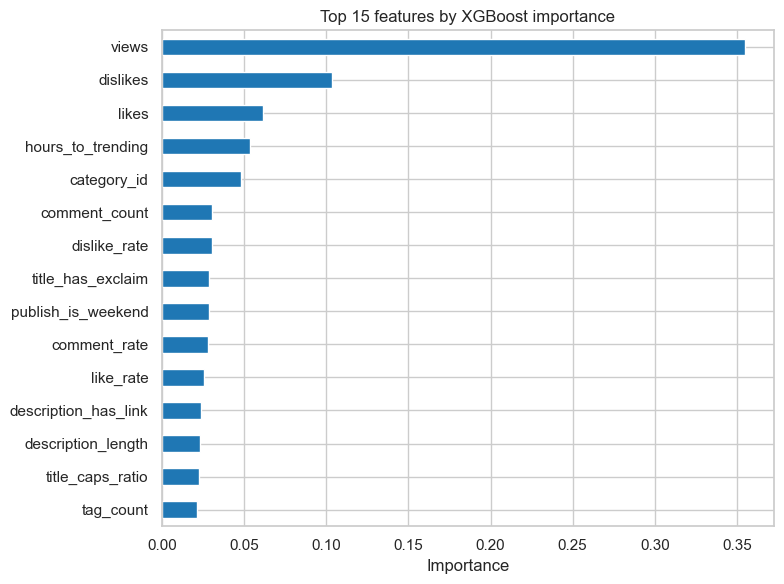

views                 0.354761
dislikes              0.103480
likes                 0.061516
hours_to_trending     0.053800
category_id           0.048402
comment_count         0.030712
dislike_rate          0.030404
title_has_exclaim     0.028703
publish_is_weekend    0.028638
comment_rate          0.028104
dtype: float32


In [12]:
imp = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15)[::-1].plot.barh(ax=ax, color='tab:blue')
ax.set_xlabel('Importance')
ax.set_title('Top 15 features by XGBoost importance')
plt.tight_layout()
plt.show()

print(imp.head(10))

## 8. SHAP — the explainable version

SHAP tells us not just which features matter overall, but which features pushed an *individual* prediction up or down. This is what we'll show on the frontend — waterfall charts explaining each prediction.

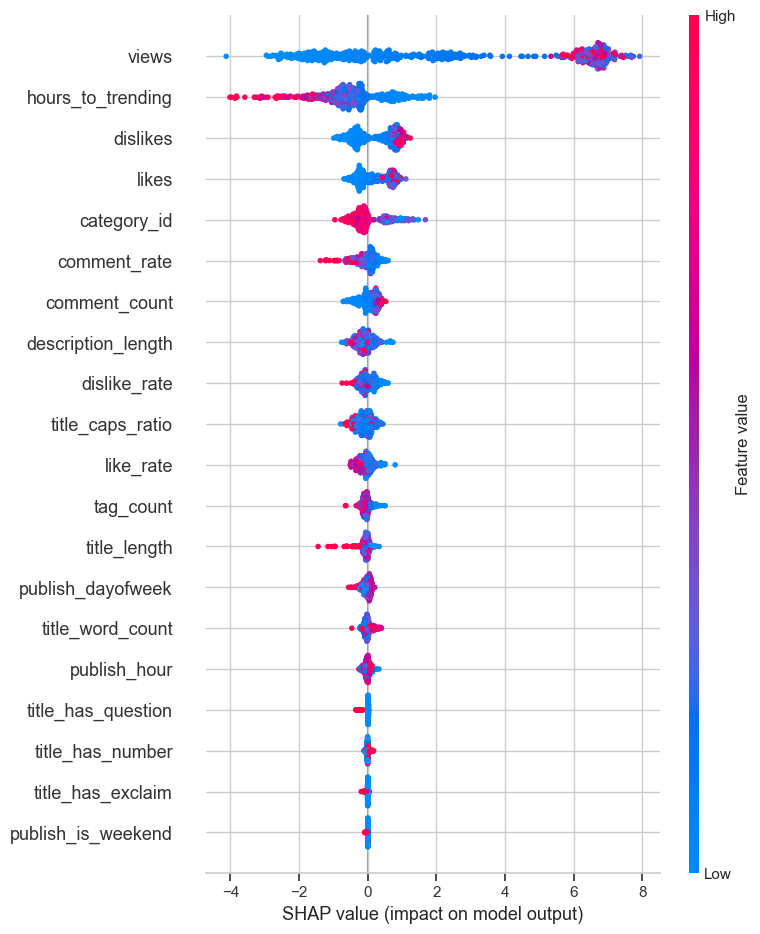

In [13]:
import shap

# Sample 500 test examples for speed
sample_idx = np.random.RandomState(42).choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot — how each feature affects predictions across the dataset
shap.summary_plot(shap_values, X_sample, show=True)

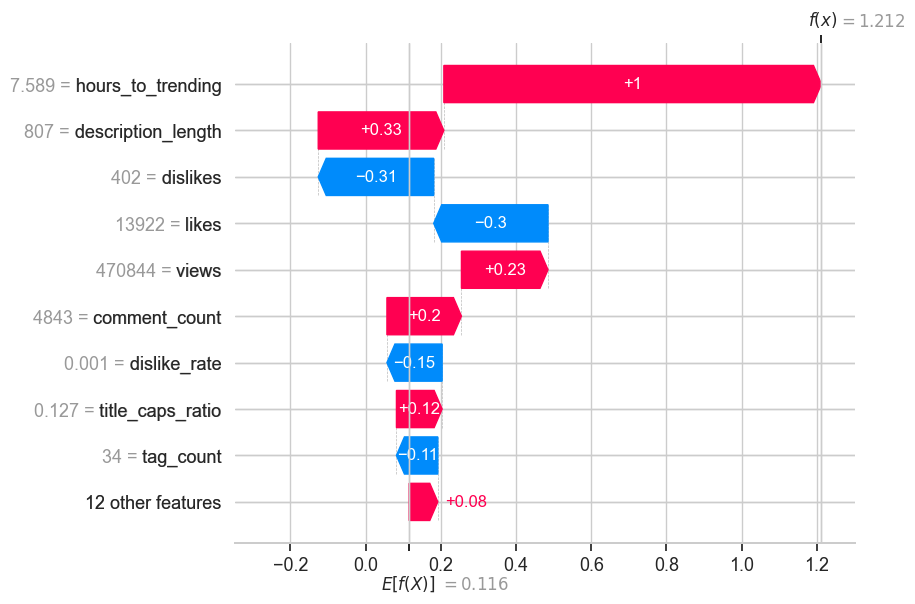

In [14]:
# Waterfall for a single prediction — what does the UI will show
idx_to_explain = 0
shap.waterfall_plot(shap.Explanation(
    values=shap_values[idx_to_explain],
    base_values=explainer.expected_value,
    data=X_sample.iloc[idx_to_explain].values,
    feature_names=feature_cols,
))

## 9. Save the model

Pickle the trained model for later use in the FastAPI backend.

In [15]:
import joblib

Path('models').mkdir(exist_ok=True)
model_path = Path('models/v0_xgboost.pkl')
joblib.dump({
    'model': model,
    'feature_cols': feature_cols,
    'viral_threshold': VIRAL_THRESHOLD,
    'trained_on': 'kaggle-usvideos-2017-2018',
    'test_auc': float(roc_auc_score(y_test, probs)),
}, model_path)

print(f'Saved to {model_path} ({model_path.stat().st_size / 1e6:.2f} MB)')

Saved to models\v0_xgboost.pkl (0.88 MB)
